## 3-Form Invariants Check

This notebook presents a nicer, cleaned-up explicit check that there are five functionally independent invariants that can be constructed from an antisymmetric 3-tensor $H_{\mu \nu \rho}$ in six Euclidean dimensions.

Compared to the previous versions of the code, we use a corrected and better-optimized function for generating the weighted graphs that represent inequivalent contractions. This function can be found in `tensor_contraction_graphs.py` and was optimized by ChatGPT.

We will also use the `opt_einsum` package, which you can install with `pip` in the usual way, to dramatically speed up the `einsum` contractions that we need to do.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/Colab\ Notebooks


/content/drive/MyDrive/Colab Notebooks


In [3]:
!pip install python-igraph


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 57.5 MB/s eta 0:00:00


In [4]:
import math
import itertools
import numpy as np
from sympy.combinatorics.named_groups import SymmetricGroup
from sympy.combinatorics import Permutation

In [5]:
from tensor_contraction_graphs import *
import opt_einsum as oe

First let's get the inequivalent contractions at order $2$.

In [6]:
G2 = get_inequivalent_graphs(2)
G2

As expected, there's only one. Let's take a look:

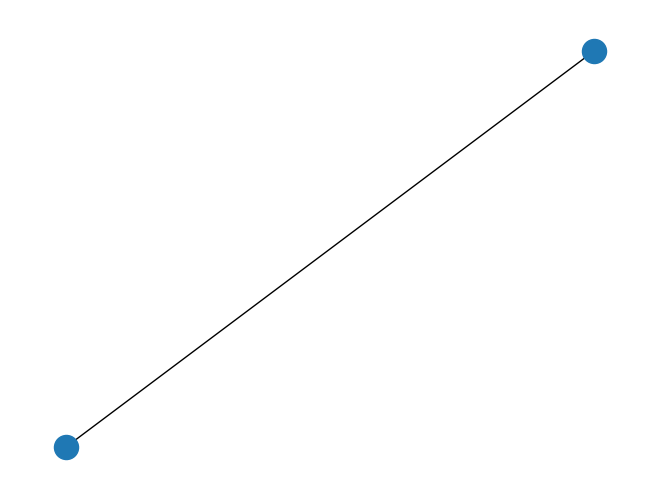

In [7]:
nx.draw(G2[0])

Good, so that one is $H_{\mu \nu \rho} H^{\mu \nu \rho}$. Next get the order $4$ guys.

In [8]:
G4 = get_inequivalent_graphs(4)
G4

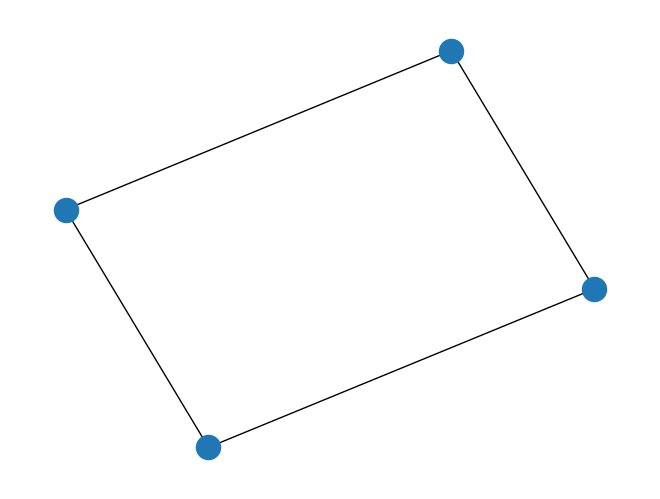

In [9]:
nx.draw(G4[0])

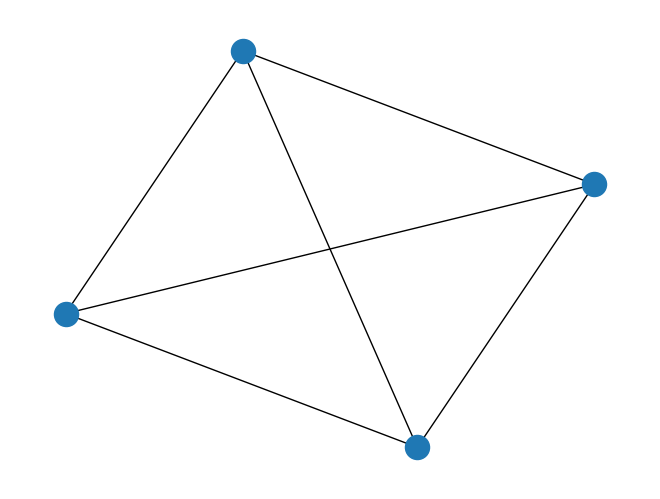

In [10]:
nx.draw(G4[1])

Now we check whether these two are independent of the square of the second-order invariant. We do this with the usual strategy of drawing three random tensors, numerically computing each of the three invariants, putting this data into a $3 \times 3$ matrix, and checking the rank.

In [11]:
data = []

for i in range(3):
    H = random_antisym(6, 3)

    y2 = oe.contract('abc, abc', H, H)

    y4 = []
    for G in G4:
        my_sum = graph_to_einsum(G)
        y4.append(float(oe.contract(my_sum, H, H, H, H)))

    this_data = [y2**2 , y4[0], y4[1]]
    data.append(this_data)

data

[[np.float64(1879.3048313899653), 531.7476056338869, 237.040581982586],
 [np.float64(2614.9069982762376), 614.5349701767773, 256.7508167535578],
 [np.float64(3100.8423117767993), 716.6272408875684, 261.080330116974]]

In [12]:
np.linalg.matrix_rank(data)

np.int64(3)

So both of the order 4 invariants are independent. Now we go to order six. First it is useful to check whether these invariants are independent on their own, before considering dependence on lower ones.

In [13]:
G6 = get_inequivalent_graphs(6)
G6

In [14]:
data = []

for i in range(len(G6)):
    H = random_antisym(6, 3)

    y6 = []
    for G in G6:
        my_sum = graph_to_einsum(G)
        y6.append(float(oe.contract(my_sum, H, H, H, H, H, H)))

    data.append(y6)

print(len(G6), np.linalg.matrix_rank(np.matrix(data)))

6 3


Three of the order-$6$ graphs are functionally independent. Let's be careful and make sure we pick three of these invariants to use which are actually indepenedent of each other.

In [15]:
indep_cols = []   # will hold the selected column-vectors
indep_idx  = []   # will hold their original column indices

for idx, vec in enumerate(data):
    # form the candidate matrix by stacking what we have + this new vec
    M = np.vstack(indep_cols + [vec])   # shape = (k+1, n_samples)

    # if the numeric rank goes up by exactly 1, this vec is independent
    if np.linalg.matrix_rank(M) == len(indep_cols) + 1:
        indep_cols.append(vec)
        indep_idx.append(idx)

print("Independent invariant indices:", indep_idx)

Independent invariant indices: [0, 1, 2]


This means that we can take the first three order-$6$ graphs and use them as our independent guys.

In [16]:
indep_G6_first_pass = [G6[0], G6[1] ,G6[2]]

So out of the six invariants at order $6$, only three are independent _within this set_. Next we check how many of these are independent _including the lower-order guys_.

In [17]:
data = []

for i in range(6):
    H = random_antisym(6, 3)

    y2 = oe.contract('abc, abc', H, H)

    y4 = []
    for G in G4:
        my_sum = graph_to_einsum(G)
        y4.append(float(oe.contract(my_sum, H, H, H, H)))

    y6 = []
    for G in indep_G6_first_pass:
        my_sum = graph_to_einsum(G)
        y6.append(float(oe.contract(my_sum, H, H, H, H, H, H)))

    this_data = [y2**3 , y2*y4[0], y2*y4[1]] + list(y6)
    data.append(this_data)

data = np.matrix(data)

print(data.shape, np.linalg.matrix_rank(data))

(6, 6) 4


There are 4 independent invariants within this collection, which means we need to keep the first three lower-order guys that we had before, plus **one more** from the set of sixth order invariants.

Importantly, we can't just take the first element of the list of order-$6$ graphs. That one turns out not to be independent. But if we take the third element, as we do below, we can see that this one is independent.

In [18]:
data = []
indep_G6 = [indep_G6_first_pass[2]]

for i in range(4):
    H = random_antisym(6, 3)

    y2 = oe.contract('abc, abc', H, H)

    y4 = []
    for G in G4:
        my_sum = graph_to_einsum(G)
        y4.append(float(oe.contract(my_sum, H, H, H, H)))

    y6 = []
    for G in indep_G6:
        my_sum = graph_to_einsum(G)
        y6.append(float(oe.contract(my_sum, H, H, H, H, H, H)))

    this_data = [y2**3 , y2*y4[0], y2*y4[1]] + list(y6)
    data.append(this_data)

data = np.matrix(data)

print(data.shape, np.linalg.matrix_rank(data))

(4, 4) 4


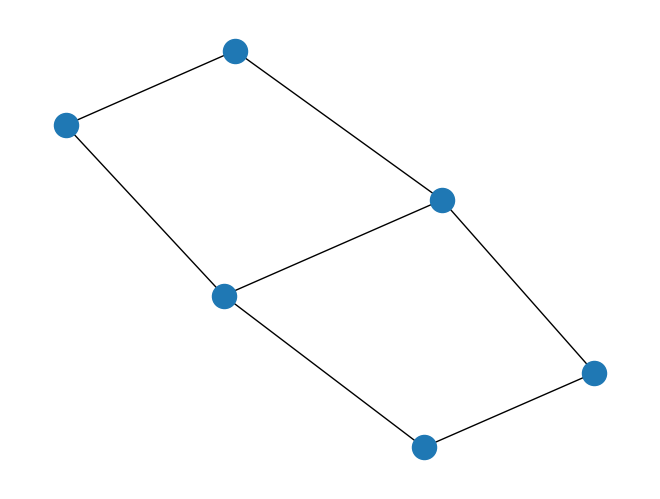

In [19]:
nx.draw(indep_G6[0])

Now we get the order 8 guys. This is starting to get a bit slower but it still runs within a few seconds on my laptop (I'm parallelizing across 12 threads with `joblib` so it might be slower if your machine has less compute).

In [20]:
data = []
G8 = get_inequivalent_graphs(8)

print(len(G8))

20


Next we continue as we were doing above and check which among these 20 invariants are independent of each other.

Because things start to slow down at this order, we will now begin pre-computing the optimized `einsum` paths for each contraction, which will save some time.

In [21]:
# 1) Precompute optimal contraction-paths for each G in G8
H_ref = random_antisym(6, 3)
paths = Parallel(n_jobs=-1, backend='threading')(
    delayed(lambda G:
        oe.contract_path(
            graph_to_einsum(G),
            H_ref, H_ref, H_ref, H_ref, H_ref, H_ref, H_ref, H_ref
        )[0]
    )(G)
    for G in G8
)

# 2) Define a function that, for a given H-index i, generates one y8 row
def compute_y8(i):
    H = random_antisym(6, 3)
    y8 = [
        float(oe.contract(
            graph_to_einsum(G),
            H, H, H, H, H, H, H, H,
            optimize=paths[ig]
        ))
        for ig, G in enumerate(G8)
    ]
    return y8

# 3) Parallelize the outer loop over i
data = Parallel(n_jobs=-1, backend='threading')(
    delayed(compute_y8)(i)
    for i in range(len(G8))
)

# convert to array and do final rank
data = np.array(data)
print(len(G8), np.linalg.matrix_rank(data))

20 6


In [22]:
data = np.array(data).T.tolist()


Now we extract a choice of $6$ of the linearly independent invariants at order $8$.

In [23]:
indep_cols = []   # will hold the selected column-vectors
indep_idx  = []   # will hold their original column indices

for idx, vec in enumerate(data):
    # form the candidate matrix by stacking what we have + this new vec
    M = np.vstack(indep_cols + [vec])   # shape = (k+1, n_samples)

    # if the numeric rank goes up by exactly 1, this vec is independent
    if np.linalg.matrix_rank(M) == len(indep_cols) + 1:
        indep_cols.append(vec)
        indep_idx.append(idx)

print("Independent invariant indices:", indep_idx)

Independent invariant indices: [0, 1, 2, 4, 6, 8]


In [24]:
indep_G8_first_pass = [G8[0],G8[1],G8[2], G8[4], G8[6], G8[8]]

Now check for dependence on the lower guys.

In [25]:
data = []

for i in range(13):
    H = random_antisym(6, 3)

    y2 = np.einsum('abc, abc', H, H)

    y4 = []
    for G in G4:
        my_sum = graph_to_einsum(G)
        y4.append(float(oe.contract(my_sum, H, H, H, H)))

    y6 = []
    my_sum = graph_to_einsum(indep_G6[0])
    y6.append(float(oe.contract(my_sum, H, H, H, H, H, H)))

    y8 = []
    for i, G in enumerate(indep_G8_first_pass):
        my_sum = graph_to_einsum(G)
        y8.append(float(oe.contract(my_sum, H, H, H, H, H, H, H, H)))

    this_data = [y2**4 , (y2**2)*y4[0], (y2**2)*y4[1], y4[0]**2, y4[1]**2, y4[0]*y4[1], y6[0]*y2] + list(y8)
    data.append(this_data)

data = np.matrix(data)
print(data.shape, np.linalg.matrix_rank(data))

(13, 13) 8


So we need to keep one of the order 8 guys. Check that taking just the first one works.

In [26]:
data = []

for i in range(8):
    H = random_antisym(6, 3)

    y2 = np.einsum('abc, abc', H, H)

    y4 = []
    for G in G4:
        my_sum = graph_to_einsum(G)
        y4.append(float(oe.contract(my_sum, H, H, H, H)))

    y6 = []
    my_sum = graph_to_einsum(indep_G6[0])
    y6.append(float(oe.contract(my_sum, H, H, H, H, H, H)))

    y8 = []
    for i, G in enumerate([indep_G8_first_pass[0]]):
        my_sum = graph_to_einsum(G)
        y8.append(float(oe.contract(my_sum, H, H, H, H, H, H, H, H)))

    this_data = [y2**4 , (y2**2)*y4[0], (y2**2)*y4[1], y4[0]**2, y4[1]**2, y4[0]*y4[1], y6[0]*y2] + list(y8)
    data.append(this_data)

data = np.matrix(data)
print(data.shape, np.linalg.matrix_rank(data))

(8, 8) 8


In [27]:
indep_G8 = [indep_G8_first_pass[0]]

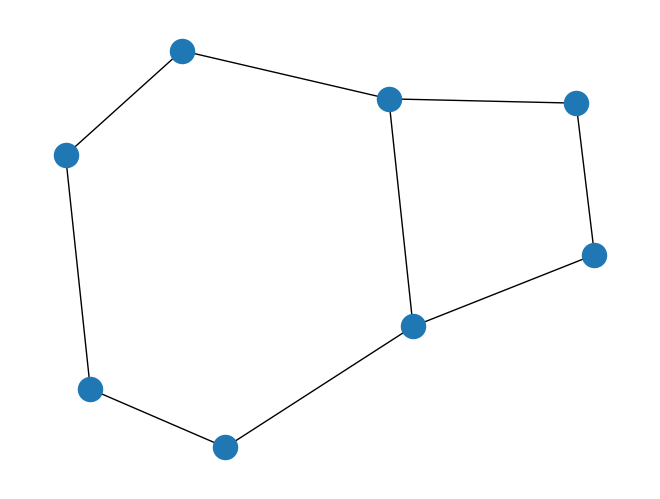

In [28]:
nx.draw(indep_G8[0])

That works!

We now have five invariants -- the order $2$ guy, the two order $4$ scalars, one order six invariant (the third one in the list), and one order 8 guy (the first one in the list).

We claim that this is a complete generating set. To check this, we now see whether all order-$10$ invariants can be written in terms of the lower ones.

In [29]:
import pickle

with open(r"graphs10.pkl", 'rb') as file:
    G10all = pickle.load(file)
print(len(G10all))

135


In [30]:
G10 = [g for g in G10all if nx.is_connected(g)]
len(G10)

91

Like before, we check how many of the $91$ connected graphs give independent contractions.

In [31]:
# 1) Precompute optimal contraction-paths for each G in G8
H_ref = random_antisym(6, 3)
paths = Parallel(n_jobs=-1, backend='threading')(
    delayed(lambda G:
        oe.contract_path(
            graph_to_einsum(G),
            H_ref, H_ref, H_ref, H_ref, H_ref, H_ref, H_ref, H_ref, H_ref, H_ref
        )[0]
    )(G)
    for G in G10
)

# 2) Define a function that, for a given H-index i, generates one y8 row
def compute_y10(i):
    H = random_antisym(6, 3)
    y10 = [
        float(oe.contract(
            graph_to_einsum(G),
            H, H, H, H, H, H, H, H, H, H,
            optimize=paths[ig]
        ))
        for ig, G in enumerate(G10)
    ]
    return y10

# 3) Parallelize the outer loop over i
data = Parallel(n_jobs=-1, backend='threading')(
    delayed(compute_y10)(i)
    for i in range(len(G10))
)

# convert to array and do final rank
data = np.array(data)
print(len(G10), np.linalg.matrix_rank(data))

91 8


In [32]:
data = np.array(data).T.tolist()


Only $8$ are independent! Let's extract a choice of these $8$ again.

In [33]:
indep_cols = []   # will hold the selected column-vectors
indep_idx  = []   # will hold their original column indices

for idx, vec in enumerate(data):
    # form the candidate matrix by stacking what we have + this new vec
    M = np.vstack(indep_cols + [vec])   # shape = (k+1, n_samples)

    # if the numeric rank goes up by exactly 1, this vec is independent
    if np.linalg.matrix_rank(M) == len(indep_cols) + 1:
        indep_cols.append(vec)
        indep_idx.append(idx)

print("Independent invariant indices:", indep_idx)

Independent invariant indices: [0, 1, 2, 3, 5, 16, 18, 21]


In [34]:
indep_G10_first_pass = [G10[0], G10[1], G10[2], G10[3], G10[5], G10[16], G10[18], G10[21]]

Finally, we need to prove that all $8$ of these are functions of lower invariants.

In [35]:
data = []

for i in range(18):
    H = random_antisym(6, 3)

    y2 = np.einsum('abc, abc', H, H)

    y4 = []
    for G in G4:
        my_sum = graph_to_einsum(G)
        y4.append(float(oe.contract(my_sum, H, H, H, H, optimize = 'greedy')))

    y6 = []
    my_sum = graph_to_einsum(indep_G6[0])
    y6.append(float(oe.contract(my_sum, H, H, H, H, H, H, optimize = 'greedy')))

    y8 = []
    my_sum = graph_to_einsum(indep_G8[0])
    y8.append(float(oe.contract(my_sum, H, H, H, H, H, H, H, H)))

    y10 = []
    for ig, G in enumerate(indep_G10_first_pass):
        my_sum = graph_to_einsum(G)
        y10.append(float(oe.contract(my_sum, H, H, H, H, H, H, H, H, H, H)))

    this_data = ([y2**5,
                 (y2**3)*y4[0],
                 (y2**3)*y4[1],
                 y2*(y4[0]**2),
                 y2*(y4[1]**2),
                 y2*y4[0]*y4[1],
                 y6[0]*y4[0],
                 y6[0]*y4[1],
                 y6[0]*y2**2,
                 y8[0]*y2]
                + list(y10) )
    data.append(this_data)

data = np.matrix(data)
print(data.shape, np.linalg.matrix_rank(data))

(18, 18) 10


The matrix is rank $10$ so everything is a function of the lower invariants!

Finally, as a sanity check, let's make sure that the matrix of just these 10 scalars is full rank.

In [36]:
data = []

for i in range(10):
    H = random_antisym(6, 3)

    y2 = np.einsum('abc, abc', H, H)

    y4 = []
    for G in G4:
        my_sum = graph_to_einsum(G)
        y4.append(float(oe.contract(my_sum, H, H, H, H, optimize = 'greedy')))

    y6 = []
    my_sum = graph_to_einsum(indep_G6[0])
    y6.append(float(oe.contract(my_sum, H, H, H, H, H, H, optimize = 'greedy')))

    y8 = []
    my_sum = graph_to_einsum(indep_G8[0])
    y8.append(float(oe.contract(my_sum, H, H, H, H, H, H, H, H)))

    this_data = ([y2**5,
                 (y2**3)*y4[0],
                 (y2**3)*y4[1],
                 y2*(y4[0]**2),
                 y2*(y4[1]**2),
                 y2*y4[0]*y4[1],
                 y6[0]*y4[0],
                 y6[0]*y4[1],
                 y6[0]*y2**2,
                 y8[0]*y2])
    data.append(this_data)

data = np.matrix(data)
print(data.shape, np.linalg.matrix_rank(data))

(10, 10) 10


In [37]:
#Code to generate code that generates the graphs
import networkx as nx

def export_graphs_literal(graphs):
    lines = ["import networkx as nx", "", "graphs = []"]
    for i, G in enumerate(graphs):
        lines.append(f"# Graph {i}")
        lines.append("G = nx.Graph()")
        lines.append(f"G.add_nodes_from({list(G.nodes())})")

        color_dict = nx.get_node_attributes(G, 'color')
        if color_dict:
            for node, color in color_dict.items():
                lines.append(f"G.nodes[{node}]['color'] = {color}")

        for u, v, data in G.edges(data=True):
            w = data.get('weight', 1)
            lines.append(f"G.add_edge({u}, {v}, weight={w})")

        lines.append("graphs.append(G)\n")

    return "\n".join(lines)

# Generate exportable code
code_string = export_graphs_literal(indep_G8)

# Print to copy-paste
print(code_string)

import networkx as nx

graphs = []
# Graph 0
G = nx.Graph()
G.add_nodes_from([0, 1, 2, 3, 4, 5, 6, 7])
G.add_edge(0, 4, weight=1)
G.add_edge(0, 7, weight=2)
G.add_edge(1, 4, weight=2)
G.add_edge(1, 6, weight=1)
G.add_edge(2, 5, weight=1)
G.add_edge(2, 6, weight=1)
G.add_edge(2, 7, weight=1)
G.add_edge(3, 5, weight=2)
G.add_edge(3, 6, weight=1)
graphs.append(G)

